In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array

In [2]:
# ✅ Update the correct dataset path
DATASET_PATH = "/kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset"

# Image dimensions
IMG_SIZE = (224, 224)

# Load dataset
def load_images(dataset_path):
    categories = ["Normal", "Ischemia", "Bleeding"]
    images = []
    labels = []

    for category in categories:
        png_folder = os.path.join(dataset_path, category, "PNG")  # Look inside PNG subfolder
        if not os.path.exists(png_folder):
            print(f"⚠️ Warning: {png_folder} not found!")
            continue

        for img_name in os.listdir(png_folder):
            img_path = os.path.join(png_folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, IMG_SIZE)  # Resize to 224x224
            img = img_to_array(img) / 255.0  # Normalize
            images.append(img)
            labels.append(category)

    return np.array(images), np.array(labels)

# Load images and labels
X, y = load_images(DATASET_PATH)

# Print dataset info
print(f"✅ Total images loaded: {len(X)}")
unique, counts = np.unique(y, return_counts=True)
print("📊 Class distribution:")
for u, c in zip(unique, counts):
    print(f" - {u}: {c} images")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

✅ Total images loaded: 6650
📊 Class distribution:
 - Bleeding: 1093 images
 - Ischemia: 1130 images
 - Normal: 4427 images


In [3]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print(f"📌 Training set size: {len(X_train)}, Test set size: {len(X_test)}")

📌 Training set size: 5320, Test set size: 1330


In [4]:

# Feature extraction using VGG16
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

def extract_features(images):
    features = feature_extractor.predict(images)
    return features.reshape(features.shape[0], -1) 

# Extract features
print("🔍 Extracting features using VGG16...")
X_train_features = extract_features(X_train)
X_test_features = extract_features(X_test)
print(f"✅ Feature shape: {X_train_features.shape}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🔍 Extracting features using VGG16...
167/167 ━━━━━━━━━━━━━━━━━━━━ 34s 129ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 314ms/step
✅ Feature shape: (5320, 25088)


In [5]:
def extract_features(images):
    features = feature_extractor.predict(images)
    return features.reshape(features.shape[0], -1) 

In [6]:
# Train SVM model
print("🚀 Training SVM classifier...")
svm_model = SVC(kernel="linear", C=1.0)
svm_model.fit(X_train_features, y_train)
print("✅ SVM training completed.")

🚀 Training SVM classifier...
✅ SVM training completed.


In [7]:
# Predict on test set
y_pred = svm_model.predict(X_test_features)

In [8]:
import matplotlib.pyplot as plt
import cv2

def predict_and_show(image_path, model, feature_extractor, label_encoder):
    """
    Predicts the class of a given image and displays it.
    """
    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        print("⚠️ Error: Image not found!")
        return

    # Convert from BGR (OpenCV default) to RGB for correct display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess the image for prediction
    img_resized = cv2.resize(img, (224, 224))  # Resize
    img_resized = img_to_array(img_resized) / 255.0  # Normalize
    img_resized = np.expand_dims(img_resized, axis=0)  # Add batch dimension

    # Extract features using VGG16
    img_features = feature_extractor.predict(img_resized)
    img_features = img_features.reshape(1, -1)  # Flatten features

    # Predict using SVM
    prediction = model.predict(img_features)[0]
    predicted_class = label_encoder.inverse_transform([prediction])[0]

    # Display the image with prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"🧠 Predicted Class: {predicted_class}", fontsize=14, fontweight="bold")
    plt.show()

    print(f"✅ Predicted Class: {predicted_class}")
    return predicted_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


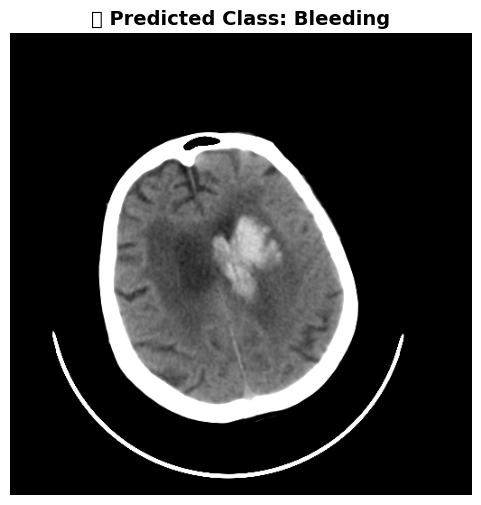

✅ Predicted Class: Bleeding


'Bleeding'

In [9]:
# Test with a new image
test_image_path = "/kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/External_Test/PNG/10007.png"
predict_and_show(test_image_path, svm_model, feature_extractor, label_encoder)

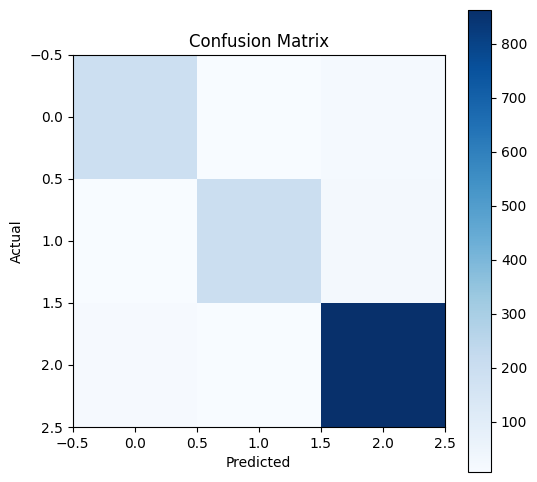

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap="Blues", interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
print("🌲 Training Random Forest classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_features, y_train)
print("✅ Random Forest training completed.")

# Predict on test set
y_rf_pred = rf_model.predict(X_test_features)


🌲 Training Random Forest classifier...
✅ Random Forest training completed.


In [12]:
def rf_predict_and_show(image_path, model, feature_extractor, label_encoder):
    """
    Predicts the class of a given image using Random Forest and displays it.
    """
    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        print("⚠️ Error: Image not found!")
        return

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess image
    img_resized = cv2.resize(img, (224, 224))
    img_resized = img_to_array(img_resized) / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)

    # Extract features
    img_features = feature_extractor.predict(img_resized)
    img_features = img_features.reshape(1, -1)

    # Predict using Random Forest
    prediction = model.predict(img_features)[0]
    predicted_class = label_encoder.inverse_transform([prediction])[0]

    # Display
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"🧠 Predicted Class: {predicted_class}", fontsize=14, fontweight="bold")
    plt.show()

    print(f"✅ Predicted Class: {predicted_class}")
    return predicted_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


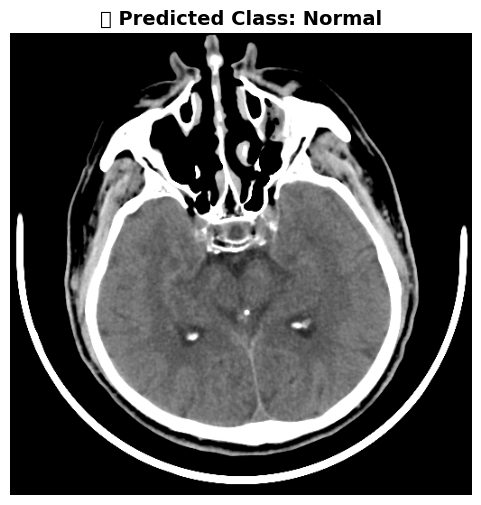

✅ Predicted Class: Normal


'Normal'

In [13]:
# Call this with the path to a new image
rf_predict_and_show("/kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/External_Test/PNG/10267.png", rf_model, feature_extractor, label_encoder)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN model
print("📍 Training K-Nearest Neighbors classifier...")
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train_features, y_train)
print("✅ KNN training completed.")

# Predict on test set
y_knn_pred = knn_model.predict(X_test_features)


📍 Training K-Nearest Neighbors classifier...
✅ KNN training completed.


In [15]:
def knn_predict_and_show(image_path, model, feature_extractor, label_encoder):
    """
    Predicts the class of a given image using KNN and displays it.
    """
    img = cv2.imread(image_path)
    if img is None:
        print("⚠️ Error: Image not found!")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    img_resized = img_to_array(img_resized) / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)

    img_features = feature_extractor.predict(img_resized)
    img_features = img_features.reshape(1, -1)

    prediction = model.predict(img_features)[0]
    predicted_class = label_encoder.inverse_transform([prediction])[0]

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"🧠 Predicted Class: {predicted_class}", fontsize=14, fontweight="bold")
    plt.show()

    print(f"✅ Predicted Class: {predicted_class}")
    return predicted_class


In [16]:
from sklearn.naive_bayes import GaussianNB

# Train Naive Bayes model
print("📊 Training Naive Bayes classifier...")
nb_model = GaussianNB()
nb_model.fit(X_train_features, y_train)
print("✅ Naive Bayes training completed.")

# Predict on test set
y_nb_pred = nb_model.predict(X_test_features)


📊 Training Naive Bayes classifier...
✅ Naive Bayes training completed.


In [17]:
def nb_predict_and_show(image_path, model, feature_extractor, label_encoder):
    """
    Predicts the class of a given image using Naive Bayes and displays it.
    """
    img = cv2.imread(image_path)
    if img is None:
        print("⚠️ Error: Image not found!")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    img_resized = img_to_array(img_resized) / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)

    img_features = feature_extractor.predict(img_resized)
    img_features = img_features.reshape(1, -1)

    prediction = model.predict(img_features)[0]
    predicted_class = label_encoder.inverse_transform([prediction])[0]

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"🧠 Predicted Class: {predicted_class}", fontsize=14, fontweight="bold")
    plt.show()

    print(f"✅ Predicted Class: {predicted_class}")
    return predicted_class


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


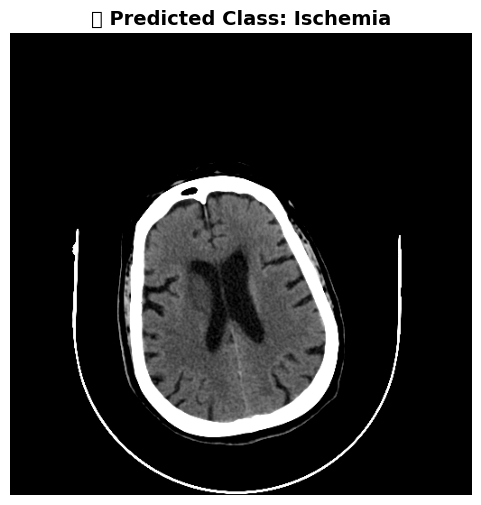

✅ Predicted Class: Ischemia
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


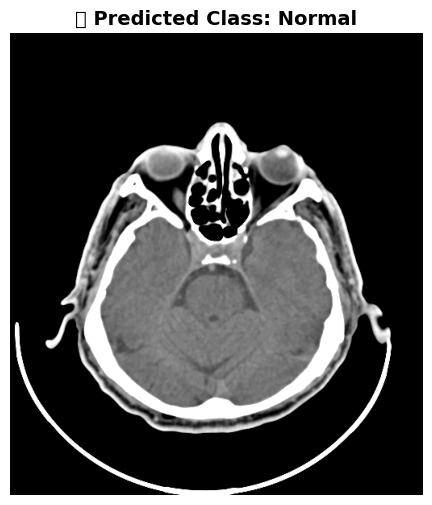

✅ Predicted Class: Normal


'Normal'

In [18]:
# For KNN
knn_predict_and_show("/kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/External_Test/PNG/11074.png", knn_model, feature_extractor, label_encoder)

# For Naive Bayes
nb_predict_and_show("/kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/External_Test/PNG/10467.png", nb_model, feature_extractor, label_encoder)


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluation
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }

# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred, "SVM"))
results.append(evaluate_model(y_test, y_rf_pred, "Random Forest"))
results.append(evaluate_model(y_test, y_knn_pred, "KNN"))
results.append(evaluate_model(y_test, y_nb_pred, "Naive Bayes"))


<ipython-input-20-38970b3ee37e>:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


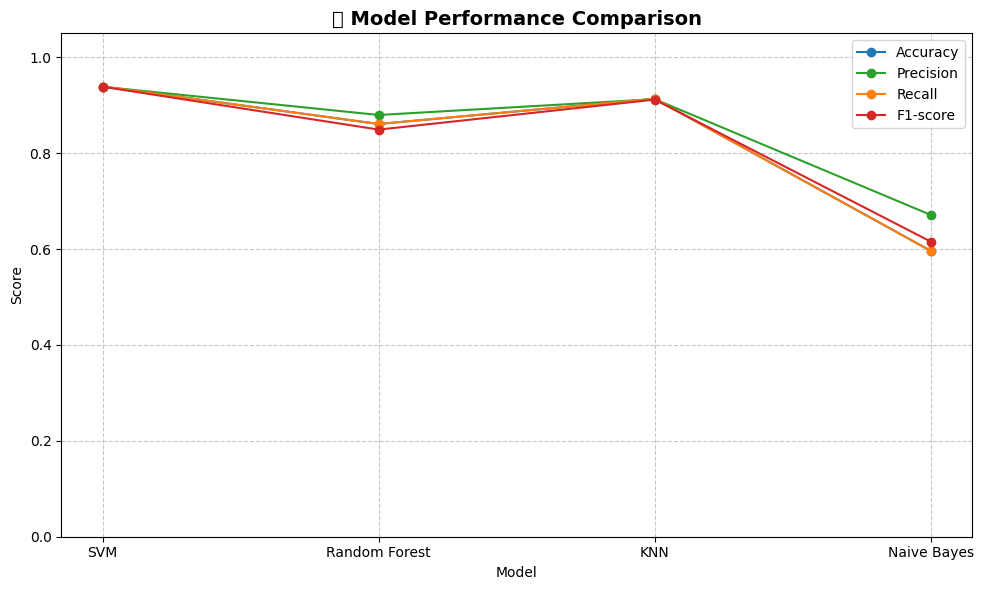

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Plotting
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

plt.figure(figsize=(10, 6))
for i, metric in enumerate(metrics):
    plt.plot(df_results["Model"], df_results[metric], marker='o', label=metric, color=colors[i])

plt.title("📊 Model Performance Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


<ipython-input-21-b8181810cb4a>:8: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


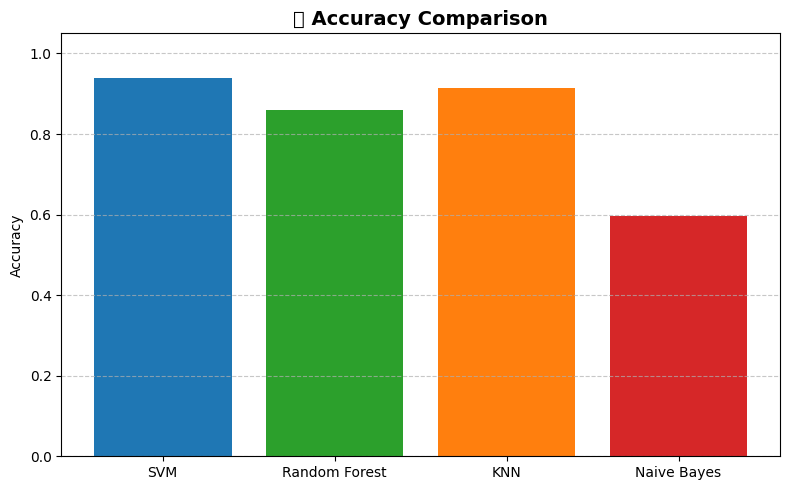

In [21]:
# Bar plot of just accuracy
plt.figure(figsize=(8, 5))
plt.bar(df_results["Model"], df_results["Accuracy"], color=colors)
plt.ylim(0, 1.05)
plt.title("✅ Accuracy Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [22]:
# Find best model for each metric
best_accuracy = df_results.loc[df_results["Accuracy"].idxmax()]
best_precision = df_results.loc[df_results["Precision"].idxmax()]
best_recall = df_results.loc[df_results["Recall"].idxmax()]
best_f1 = df_results.loc[df_results["F1-score"].idxmax()]

print("🏆 Best Models per Metric:")
print(f"🔹 Accuracy: {best_accuracy['Model']} ({best_accuracy['Accuracy']:.4f})")
print(f"🔹 Precision: {best_precision['Model']} ({best_precision['Precision']:.4f})")
print(f"🔹 Recall: {best_recall['Model']} ({best_recall['Recall']:.4f})")
print(f"🔹 F1-score: {best_f1['Model']} ({best_f1['F1-score']:.4f})")


🏆 Best Models per Metric:
🔹 Accuracy: SVM (0.9391)
🔹 Precision: SVM (0.9385)
🔹 Recall: SVM (0.9391)
🔹 F1-score: SVM (0.9386)


In [23]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


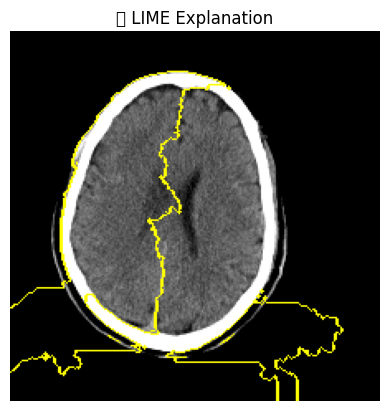

In [29]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np

# Prepare the explainer
explainer = lime_image.LimeImageExplainer()

# Custom prediction function using your pipeline
def predict_fn(images):
    # Normalize, extract features, and predict probabilities
    processed_imgs = images.astype(np.float32) / 255.0
    features = feature_extractor.predict(processed_imgs)
    features = features.reshape(features.shape[0], -1)
    return rf_model.predict_proba(features)  # or svm_model

# Select one image
img = cv2.imread("/kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/External_Test/PNG/10958.png")
img = cv2.resize(img, (224, 224))

# Explain
explanation = explainer.explain_instance(
    image=img,
    classifier_fn=predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# Visualize explanation
from matplotlib import pyplot as plt

temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    hide_rest=False,
    num_features=5,
    min_weight=0.0
)

plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("🟢 LIME Explanation")
plt.axis('off')
plt.show()